# <span style="color: #0000FF;">Анализ покупательского поведения на основе данных интернет-магазина</span>

## <span style="color: #0000FF;">Введение</span>
В современном мире электронной коммерции понимание поведения покупателей является ключевым фактором успеха бизнеса. Каждая транзакция содержит ценную информацию о предпочтениях клиентов, их покупательских привычках и факторах, влияющих на принятие решений о покупке.

Данный проект посвящен анализу реальных транзакционных данных интернет-магазина, специализирующегося на продаже подарочных товаров. Набор данных содержит информацию о 541,910 транзакциях, совершенных в период с декабря 2010 по декабрь 2011 года. Анализ позволит выявить ключевые закономерности в покупательском поведении, определить наиболее ценные сегменты клиентов и разработать рекомендации для повышения эффективности бизнес-процессов.

В ходе работы будет проведена комплексная предобработка данных, включающая очистку от аномалий, обработку пропусков и дубликатов, а также подготовку данных для дальнейшего аналитического исследования.

## <span style="color: #0000FF;">Цели и задачи проекта </span>
### Основная цель
Провести комплексный анализ транзакционных данных для выявления закономерностей покупательского поведения и разработки рекомендаций по оптимизации маркетинговых стратегий и улучшению клиентского опыта.

### Конкретные задачи
####  Предобработка и очистка данных:

1. Удаление аномальных значений (отрицательные количества и цены)

2. Обработка пропусков в данных о клиентах

3. Устранение дубликатов с учетом бизнес-логики

4. Создание признаков для дальнейшего анализа

#### Исследовательский анализ данных (EDA):

1. Анализ распределения количества товаров в заказе

2. Анализ распределения покупок по времени

3. Изучение географии продаж

4. Выявление топ-товаров и категорий

#### Сегментация клиентов:

1. Проведение RFM-анализа (Recency, Frequency, Monetary)

2. Выявление наиболее ценных клиентских сегментов

#### Анализ корзины покупок:

1. Выявление часто покупаемых вместе товаров

2. Разработка рекомендаций для cross-selling

#### Формулирование бизнес-рекомендаций:

1. Предложения по персонализации маркетинговых кампаний

2. Рекомендации по управлению товарным ассортиментом

## <span style="color: #0000FF;">Описание данных</span>

Данные представляют собой транзакционную историю интернет-магазина, специализирующегося на продаже подарков и товаров для дома. Период данных: декабрь 2010 - декабрь 2011 года.
Данные взяты из открытого источника Kaggle:[Скачать датасет](https://www.kaggle.com/datasets/ulrikthygepedersen/online-retail-dataset/versions/2?resource=download)

Исходный датасет содержит 541,910 строк и 8 столбцов:

Описание структуры данных

| Название столбца | Тип данных | Описание |
|-----------------|------------|----------|
| **InvoiceNo** | `object` | Номер заказа/счета. Уникальный идентификатор транзакции. Заказы с возвратами имеют префикс 'C' |
| **StockCode** | `object` | Уникальный код товара |
| **Description** | `object` | Наименование товара |
| **Quantity** | `float` | Количество единиц товара в заказе. Может быть отрицательным при возвратах |
| **InvoiceDate** | `object` | Дата и время совершения покупки |
| **UnitPrice** | `float` | Цена за единицу товара (в фунтах стерлингов) |
| **CustomerID** | `float` | Уникальный идентификатор клиента. Может отсутствовать для анонимных покупок |
| **Country** | `object` | Страна проживания клиента |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from itertools import combinations
from collections import Counter

In [2]:
df = pd.read_csv("C:/temp/online_retail.csv")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541910 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  float64
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(3), object(5)
memory usage: 33.1+ MB


##  <span style="color: #0000FF;">1 Предобработка и очистка данных</span>

In [4]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Здесь видно аномалии в столбцах Quantity и UnitPrice, количество и цена не могут быть отрицательными значениями, ниже произведем очистку

In [5]:
df.duplicated().sum()

5268

In [6]:
duplicates = df[df.duplicated(keep = False)]
duplicates

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1.0,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1.0,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1.0,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1.0,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1.0,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1.0,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1.0,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1.0,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1.0,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


Проверим дубликаты по паре: номер заказа + номер товара, чтобы исключить дубликаты по основным признакам

In [7]:
duplicates_invoice_stockcode = df.duplicated(subset=['InvoiceNo','StockCode'],keep = False).sum()
duplicates_invoice_stockcode

20378

In [8]:
df.isna().sum()

InvoiceNo           0
StockCode           1
Description      1455
Quantity            1
InvoiceDate         1
UnitPrice           1
CustomerID     135081
Country             1
dtype: int64

In [9]:
df_no_customer = df[df['CustomerID'].isna()]
print(f"Строк без CustomerID: {len(df_no_customer)}")
print(f"Это {len(df_no_customer)/len(df)*100:.1f}% от всех данных\n")

Строк без CustomerID: 135081
Это 24.9% от всех данных



Для общего анализа df_for_general_analysis (оставим строки с пустыми id, но заменим их на специальное значение '0', которое булет означать анонимную покупку)

In [10]:
df_for_general_analysis = df.copy()
df_for_general_analysis['CustomerID'] = df_for_general_analysis['CustomerID'].fillna(0) # 0 = анонимный покупатель

In [11]:
df_for_general_analysis.nunique() 

InvoiceNo      25901
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4373
Country           38
dtype: int64

In [12]:
df_for_general_analysis.isna().sum()

InvoiceNo         0
StockCode         1
Description    1455
Quantity          1
InvoiceDate       1
UnitPrice         1
CustomerID        0
Country           1
dtype: int64

Осталось удалить пустые строки для общего  с номером товара, страной, ценой на товар - это может быть тезническая ошибка или потеря данных, пустое описание товарной карточки не представляет вреда для качества проведения исследования, можно оставить как есть

In [13]:
df_for_general_analysis = df_for_general_analysis.dropna(subset = ['StockCode']).copy()

In [14]:
df_for_general_analysis.drop_duplicates(subset=['InvoiceNo', 'StockCode'], keep='first')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France


Если дубликаты возникли из-за разделения товаров в заказе (например, один товар добавили несколько раз в один заказ), то имеет смысл воспользоваться агрегацией и объединить количество товара в заказе в одну строку, нижу прописана функция по комплексной очистке датасета

In [15]:
def clean_dataframe(df):
    df_clean = df.copy()
    
    # 1. Удаляем полные дубликаты
    df_clean = df_clean.drop_duplicates(keep='first')
    
    # 2. Агрегируем дубликаты по ключевым полям
    # Добавляем общую сумму для взвешенной цены
    df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']
    
    # Группируем и агрегируем
    df_clean = df_clean.groupby(
        ['InvoiceNo', 'StockCode', 'CustomerID', 'Country'],
        as_index=False
    ).agg({
        'Quantity': 'sum',
        'TotalAmount': 'sum',
        'UnitPrice': 'mean',
        'InvoiceDate': 'first',
        'Description': 'first'
    })
    # 3. Удаляем отрицательные количества (возвраты)
    df_clean = df_clean[df_clean['Quantity'] > 0]
    
    # 4. Удаляем отрицательные цены
    df_clean = df_clean[df_clean['UnitPrice'] > 0]
    
    # 5. Преобразуем формат даты
    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
    
    return df_clean

# Применяем очистку
df_final = clean_dataframe(df_for_general_analysis)

In [16]:
df_final.duplicated().sum()

0

In [17]:
df_final.head()

,InvoiceNo,StockCode,CustomerID,Country,Quantity,TotalAmount,UnitPrice,InvoiceDate,Description
0,536365,21730,17850.0,United Kingdom,6.0,25.50,4.25,2010-12-01 08:26:00,GLASS STAR FROSTED T-LIGHT HOLDER
1,536365,22752,17850.0,United Kingdom,2.0,15.30,7.65,2010-12-01 08:26:00,SET 7 BABUSHKA NESTING BOXES
2,536365,71053,17850.0,United Kingdom,6.0,20.34,3.39,2010-12-01 08:26:00,WHITE METAL LANTERN
3,536365,84029E,17850.0,United Kingdom,6.0,20.34,3.39,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.
4,536365,84029G,17850.0,United Kingdom,6.0,20.34,3.39,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE


In [18]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 519602 entries, 0 to 522083
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    519602 non-null  object        
 1   StockCode    519602 non-null  object        
 2   CustomerID   519602 non-null  float64       
 3   Country      519602 non-null  object        
 4   Quantity     519602 non-null  float64       
 5   TotalAmount  519602 non-null  float64       
 6   UnitPrice    519602 non-null  float64       
 7   InvoiceDate  519602 non-null  datetime64[ns]
 8   Description  519602 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 39.6+ MB


##  <span style="color: #0000FF;">2 Исследовательский анализ данных</span>

### Анализ распределения количества товаров в заказе

Статистика по количеству товаров в заказе:
Минимум: 1 товаров
Максимум: 1110 товаров
Среднее: 26.0
Медиана: 15


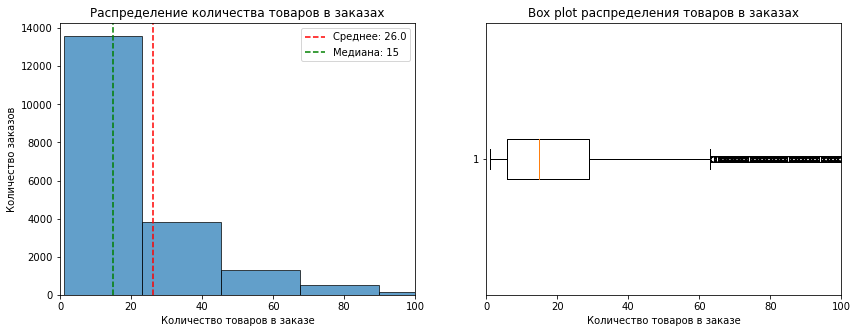

In [19]:
items_per_invoice = df_final.groupby('InvoiceNo').size()

# Статистика
print("Статистика по количеству товаров в заказе:")
print(f"Минимум: {items_per_invoice.min()} товаров")
print(f"Максимум: {items_per_invoice.max()} товаров")
print(f'Среднее: {items_per_invoice.mean():.1f}')
print(f'Медиана: {items_per_invoice.median():.0f}')

# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(items_per_invoice, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(items_per_invoice.mean(), color='red', linestyle='--', label=f'Среднее: {items_per_invoice.mean():.1f}')
axes[0].axvline(items_per_invoice.median(), color='green', linestyle='--', label=f'Медиана: {items_per_invoice.median():.0f}')
axes[0].set_xlabel('Количество товаров в заказе')
axes[0].set_ylabel('Количество заказов')
axes[0].set_title('Распределение количества товаров в заказах')
axes[0].legend()
axes[0].set_xlim(0, 100)

# Box plot
axes[1].boxplot(items_per_invoice, vert=False)
axes[1].set_xlabel('Количество товаров в заказе')
axes[1].set_title('Box plot распределения товаров в заказах')
axes[1].set_xlim(0, 100);

Основная масса клиентов совершает покупки небольшими корзинами (до 15 позиций), однако существует сегмент крупных покупателей, значительно увеличивающих средний показатель. Для анализа покупательского поведения целесообразно рассматривать эти группы отдельно или использовать медиану как более репрезентативную метрику типичного заказа.

### Анализ распределения покупок по времени

In [20]:
df_final['Month'] = df_final['InvoiceDate'].dt.month
df_final['Hour'] = df_final['InvoiceDate'].dt.hour
df_final['DayOfWeek'] = df_final['InvoiceDate'].dt.day_name()

In [21]:
df_final['DayOfWeek'].unique()

array(['Wednesday', 'Thursday', 'Friday', 'Sunday', 'Monday', 'Tuesday'],
      dtype=object)

В субботу данных не найдено, это может быть связано с особенностями работы магазина

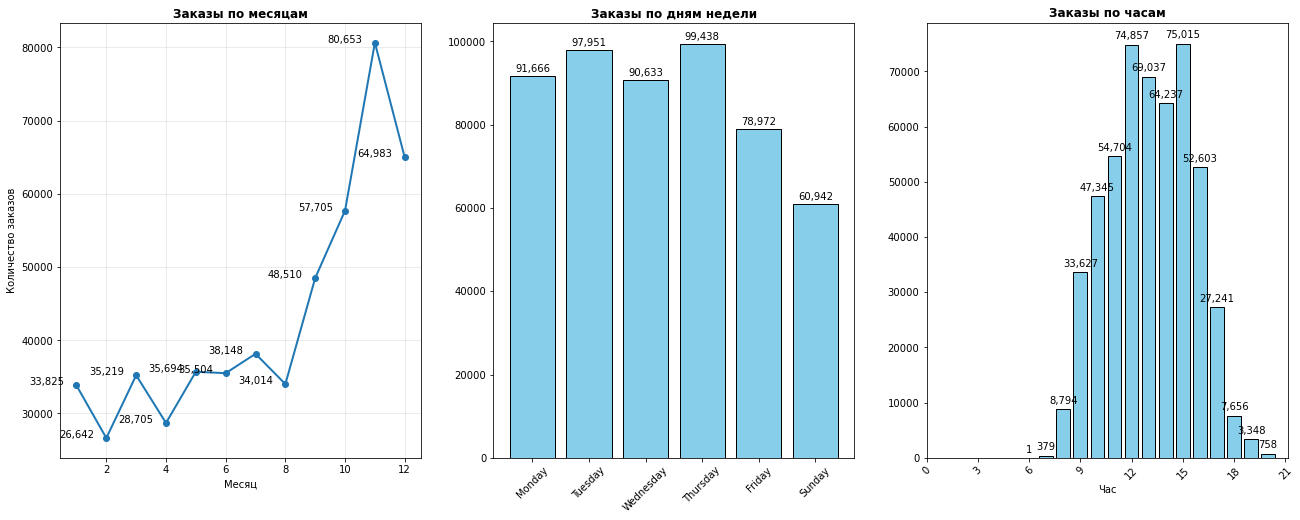

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

monthly = df_final.groupby('Month').size()
axes[0].plot(monthly.index, monthly.values, marker = 'o', linewidth=2)
axes[0].set_title('Заказы по месяцам', fontweight='bold')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Количество заказов')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(monthly):
    axes[0].text(i, v + 50, f'{round(v):,}', ha='center')

day_of_week = df_final.groupby('DayOfWeek').size().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday'])
axes[1].bar(day_of_week.index, day_of_week.values, color='skyblue', edgecolor='black')
axes[1].set_title('Заказы по дням недели', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(day_of_week):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center')
    
hours = df_final.groupby('Hour').size()
axes[2].bar(hours.index, hours.values, color='skyblue', edgecolor='black')
axes[2].set_title('Заказы по часам', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_xlabel('Час')
axes[2].set_xticks(range(0, 24, 3))
for i, v in enumerate(hours):
    axes[2].text(i+ 6, v + 1000, f'{v:,}', ha='center');

Вывод:

По месяцам:
Пик продаж: предновогодний сезон (основной фокус магазина на подарочных вещах)

Спад: январь-август  - низкие продажи до 40000 единиц за месяц

По дням недели:
Наибольшая активность: вторник-четверг, рабочие дни

Наименьшая активность: воскресенье (выходной день, люди мало времени уделяют онлайн покупкам, предпочитают офлайн отдых)

Суббота: заказы отсутствуют (вероятно, выходной день магазина)

По часам:
Часы пик: 11:00-16:00 (обеденное\рабочее время)

Низкая активность: 19:00-8:00 (ночное-нерабочее время)

### Изучение географии продаж

In [23]:
geo = df_final.groupby('Country').agg(
    Orders=('InvoiceNo', 'nunique'),
    Items=('Quantity', 'sum'),
    Revenue=('TotalAmount', 'sum'),
    Customers=('CustomerID', 'nunique')
).round(2).sort_values('Revenue', ascending=False)
geo['Avg_sum'] = (geo['Revenue'] / geo['Orders']).round(1)
top10 = geo.head(10)
top10

,Orders,Items,Revenue,Customers,Avg_sum
Country,,,,,
United Kingdom,18019,4646934.0,9001744.09,3921,499.6
Netherlands,94,200361.0,285446.34,9,3036.7
EIRE,288,147007.0,283140.52,4,983.1
Germany,457,119154.0,228678.40,94,500.4
France,392,112060.0,209625.37,88,534.8
Australia,57,83891.0,138453.81,9,2429.0
Spain,90,27933.0,61558.56,30,684.0
Switzerland,54,30618.0,57067.60,22,1056.8
Belgium,98,23237.0,41196.34,25,420.4


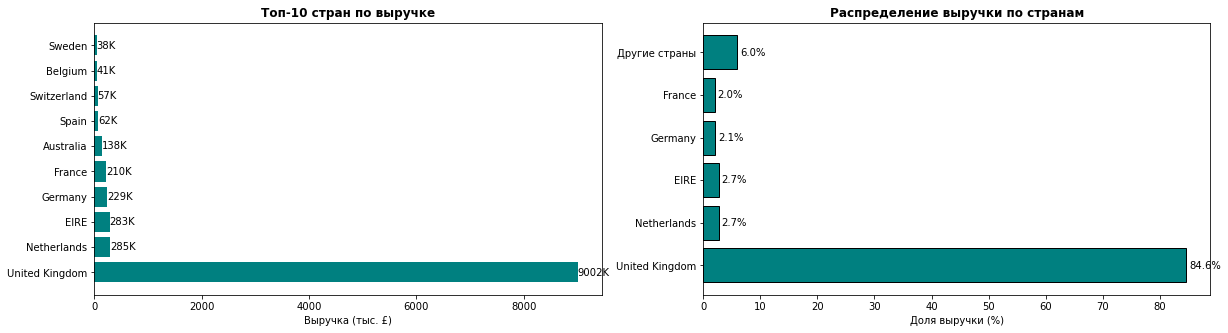

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
# 1. Топ-10 стран по выручке
axes[0].barh(range(len(top10)), top10['Revenue'] / 1000, color='teal')
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels(top10.index)
axes[0].set_xlabel('Выручка (тыс. £)')
axes[0].set_title('Топ-10 стран по выручке', fontweight='bold')
for i, v in enumerate(top10['Revenue'] / 1000):
    axes[0].text(v + 1, i, f'{v:.0f}K', va='center')

# 2. Доли выручки 
top5 = geo.head(5)
other_revenue = geo.iloc[5:]['Revenue'].sum()
distribution_data = pd.DataFrame({
    'Country': list(top5.index) + ['Другие страны'],
    'Revenue': list(top5['Revenue']) + [other_revenue]
})
total_revenue = distribution_data['Revenue'].sum()
distribution_data['Revenue_Percent'] = (distribution_data['Revenue'] / total_revenue * 100).round(1)
axes[1].barh(distribution_data['Country'], distribution_data['Revenue_Percent'], 
             color='teal', edgecolor='black')
axes[1].set_xlabel('Доля выручки (%)')
axes[1].set_title('Распределение выручки по странам', fontweight='bold')
for i, v in enumerate(distribution_data['Revenue_Percent']):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center')

Сильная концентрация: Великобритания генерирует 84.6% всей выручки – бизнес сильно зависит от внутреннего рынка.

Европейское доминирование: Топ-5 международных рынков – все европейские страны, что указывает на логистические и маркетинговые преимущества внутри Европы.

Потенциал роста: Остальные 32 страны дают всего 6% выручки – есть возможность для расширения присутствия на новых рынках.

Средний чек: Страны с малым количеством заказов (Швеция, Австралия, Швейцария) демонстрируют высокий средний чек, что говорит о наличии нишевого спроса.

### Выявление топ-товаров и категорий

In [25]:
# топ 10 товаров по выручке
top_products_revenue = df_final.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'TotalAmount': 'sum',
    'CustomerID': 'nunique'
}).round(1).sort_values('TotalAmount', ascending= False).head(10)
# топ 10 товаров по количеству продаж
top_products_quantity = df_final.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'TotalAmount': 'sum',
    'CustomerID': 'nunique'
}).round(1).sort_values('Quantity', ascending= False).head(10)

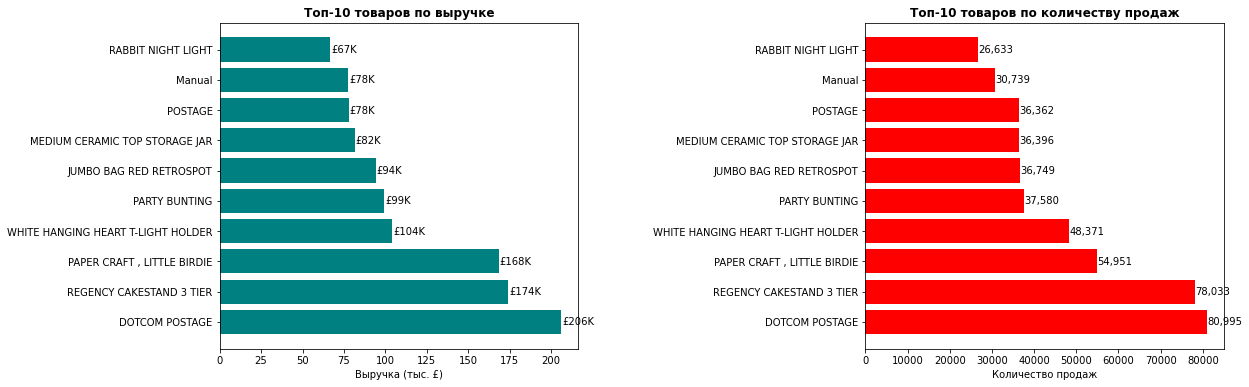

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'wspace': 0.8})

# 1. Топ-10 по выручке (горизонтальный бар)
axes[0].barh(range(len(top_products_revenue)), top_products_revenue['TotalAmount'] / 1000, color='teal')
axes[0].set_yticks(range(len(top_products_revenue)))
axes[0].set_yticklabels([desc[1][:40] + '...' if len(desc[1]) > 40 else desc[1] for desc in top_products_revenue.index])
axes[0].set_xlabel('Выручка (тыс. £)')
axes[0].set_title('Топ-10 товаров по выручке', fontweight='bold')
for i, v in enumerate(top_products_revenue['TotalAmount'] / 1000):
    axes[0].text(v + 0.5, i, f'£{v:.0f}K', va='center')

# 2. Топ-10 по количеству продаж
axes[1].barh(range(len(top_products_quantity)), top_products_quantity['Quantity'], color='red')
axes[1].set_yticks(range(len(top_products_quantity)))
axes[1].set_yticklabels([desc[1][:40] + '...' if len(desc[1]) > 40 else desc[1] for desc in top_products_revenue.index])
axes[1].set_xlabel('Количество продаж')
axes[1].set_title('Топ-10 товаров по количеству продаж', fontweight='bold')
for i, v in enumerate(top_products_quantity['Quantity']):
    axes[1].text(v + 50, i, f'{int(v):,}', va='center')

При одинаковом распределении количества продаж и выручки по категориям можно сделать следующие выводы.

Во-первых, это свидетельствует об однородной ценовой структуре ассортимента — средняя цена товара во всех категоринах примерно одинакова, что исключает наличие явных категорий-дискаунтеров или премиальных сегментов с высокой маржинальностью.

Во-вторых, магазин работает в едином ценовом коридоре, где рост объёма продаж линейно ведёт к пропорциональному росту выручки, что упрощает прогнозирование и управление товарными группами.

В-третьих, отсутствие категорий, которые давали бы непропорционально высокую выручку при скромных объёмах продаж, говорит о том, что бизнес не использует стратегию дифференцированного ценообразования и не выделяет высокомаржинальные ниши.

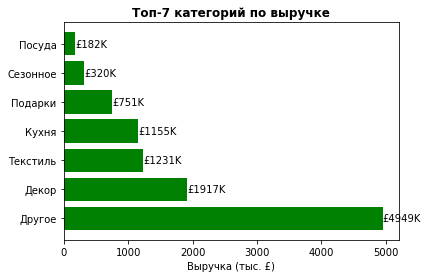

In [27]:
# Функция для определения категории по описанию
def categorize_product(description):
    desc = str(description).upper()
    categories = {
        'Декор': ['HEART', 'HANGING', 'DECOR', 'CANDLE', 'LIGHT', 'LANTERN', 'CLOCK', 'MIRROR'],
        'Кухня': ['BOTTLE', 'MUG', 'CUP', 'PLATE', 'BOWL', 'CAKESTAND', 'TEA', 'COFFEE'],
        'Текстиль': ['BAG', 'CUSHION', 'TOWEL', 'APRON', 'BLANKET', 'PILLOW'],
        'Подарки': ['GIFT', 'CARD', 'WRAPPING', 'BAG', 'BOX', 'WRAP'],
        'Посуда': ['PLATE', 'BOWL', 'DISH', 'CUTLERY', 'MUG', 'GLASS'],
        'Детское': ['CHILDREN', 'KIDS', 'BABY', 'DOLL', 'TOY'],
        'Сезонное': ['CHRISTMAS', 'XMAS', 'HALLOWEEN', 'EASTER', 'VALENTINE']
    }
    for category, keywords in categories.items():
        if any(keyword in desc for keyword in keywords):
            return category
    return 'Другое'
df_final['Category'] = df_final['Description'].apply(categorize_product)

# Анализ по категориям
category_stats = df_final.groupby('Category').agg({
    'TotalAmount': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'nunique',
    'StockCode': 'nunique'
}).round(2).sort_values('TotalAmount', ascending=False)

total_rev = category_stats['TotalAmount'].sum()
category_stats['Revenue_Share'] = (category_stats['TotalAmount'] / total_rev * 100).round(1)

fig = figsize=(22, 10)

# Топ-7 категорий по выручке (горизонтальный бар)
top7_cat = category_stats.head(7)
plt.barh(top7_cat.index, top7_cat['TotalAmount'] / 1000, color='green')
plt.xlabel('Выручка (тыс. £)')
plt.title('Топ-7 категорий по выручке', fontweight='bold')
for i, v in enumerate(top7_cat['TotalAmount'] / 1000):
    plt.text(v + 1, i, f'£{v:.0f}K', va='center');

Декор – безусловный лидер среди классифицированных товаров (18% выручки)

Текстиль и Кухня формируют второй эшелон с долями 11.6% и 10.9% соответственно

Подарки, Сезонное и Посуда занимают нишевые позиции

Категория «Другое» занимает 46.5% выручки, что указывает на необходимость доработки системы категоризации или наличие широкого ассортимента товаров, не попадающих под стандартные категории

## <span style="color: #0000FF;">3 Сегментация клиентов</span>

### RFM - анализ

RFM-анализ — метод сегментации клиентской базы по трём ключевым показателям: 
- Recency (давность) — время, прошедшее с момента последней покупки;
- Frequency (частота) — количество покупок за определённый период;
- Monetary (денежная ценность) — сумма, которую клиент потратил за анализируемый период.

In [28]:
# ипользуем только идентифицированных клиентов
rfm_data = df_final[df_final['CustomerID']>0].copy()
# определяем дату анализа (максимальная дата в данных + 1 день)
analysis_date = rfm_data['InvoiceDate'].max() + pd.Timedelta(days = 1)
rfm = rfm_data.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (analysis_date - x.max()).days ),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('TotalAmount', 'sum')
).reset_index() 

rfm = rfm[rfm['Monetary'] > 0] #удалим выбросы

In [29]:
# Recency: чем меньше, тем лучше (обратный порядок)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop')

# Frequency: чем больше, тем лучше
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4], duplicates='drop')

# Monetary: чем больше, тем лучше
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop')

# Создаем комбинированный RFM-ск
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Создаем сегменты на основе RFM-скора
def rfm_segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Чемпионы'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Лояльные'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'Новые'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'Спящие гиганты'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Уходящие'
    else:
        return 'Обычные'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

segment_counts = rfm['Segment'].value_counts()
segment_counts

Уходящие          1504
Лояльные          1034
Спящие гиганты     646
Чемпионы           489
Обычные            431
Новые              234
Name: Segment, dtype: int64

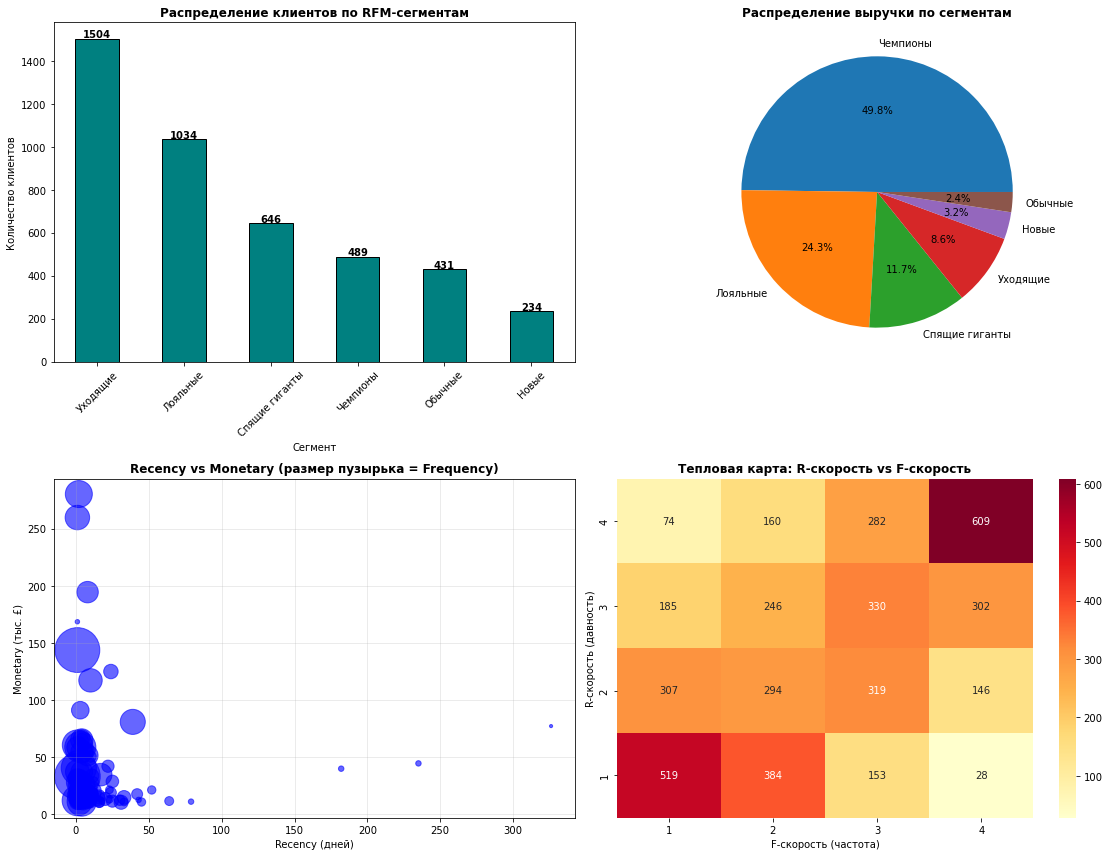

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение клиентов по сегментам
segment_counts.plot(kind='bar', ax=axes[0,0], color='teal', edgecolor='black')
axes[0,0].set_title('Распределение клиентов по RFM-сегментам', fontweight='bold')
axes[0,0].set_xlabel('Сегмент')
axes[0,0].set_ylabel('Количество клиентов')
axes[0,0].tick_params(axis='x', rotation=45)

for i, v in enumerate(segment_counts.values):
    axes[0,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Выручка по сегментам
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[0,1].pie(segment_revenue.values, labels=segment_revenue.index, autopct='%1.1f%%')
axes[0,1].set_title('Распределение выручки по сегментам', fontweight='bold')

# 3. Recency vs Monetary (пузырьковая диаграмма)
# Берем топ-100 клиентов для наглядности
top_clients = rfm.nlargest(100, 'Monetary')
scatter = axes[1,0].scatter(top_clients['Recency'], top_clients['Monetary'] / 1000, 
                            s=top_clients['Frequency']*10, alpha=0.6, c='blue')
axes[1,0].set_xlabel('Recency (дней)')
axes[1,0].set_ylabel('Monetary (тыс. £)')
axes[1,0].set_title('Recency vs Monetary (размер пузырька = Frequency)', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 4. Тепловая карта RFM-сегментов
rfm_pivot = rfm.groupby(['R_Score', 'F_Score']).size().unstack(fill_value=0)
sns.heatmap(rfm_pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,1])
axes[1,1].set_title('Тепловая карта: R-скорость vs F-скорость', fontweight='bold')
axes[1,1].set_xlabel('F-скорость (частота)')
axes[1,1].set_ylabel('R-скорость (давность)')

plt.tight_layout()
plt.show()

In [31]:
# Анализ каждого сегмента
segment_analysis = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2).sort_values('Monetary', ascending=False)

segment_analysis['Revenue_Share'] = (segment_analysis['Monetary'] * segment_analysis['CustomerID']) / rfm['Monetary'].sum() * 100
segment_analysis['Revenue_Share'] = segment_analysis['Revenue_Share'].round(1)


print(segment_analysis.to_string())


for segment in segment_analysis.index:
    print(f"\n {segment}:")
    if segment == 'Чемпионы':
        print("   Описание: Лучшие клиенты, покупают часто и недавно, высокая выручка")
        print("   Рекомендации: VIP-программа, эксклюзивные предложения, программа лояльности")
    elif segment == 'Лояльные':
        print("   Описание: Постоянные клиенты, регулярно покупают")
        print("   Рекомендации: Программа лояльности, персональные скидки, рекомендации")
    elif segment == 'Новые':
        print("   Описание: Недавние покупки, но мало покупок в истории")
        print("   Рекомендации: Вовлекающие акции, welcome-бонусы, email-рассылки")
    elif segment == 'Спящие гиганты':
        print("   Описание: Много покупали раньше, но давно не активны")
        print("   Рекомендации: Кампании по возврату, персональные предложения")
    elif segment == 'Уходящие':
        print("   Описание: Давно не покупают, мало покупок в истории")
        print("   Рекомендации: Активационные акции, опросы о причинах ухода")
    else:
        print("   Описание: Средние клиенты, требуют внимания для удержания")
        print("   Рекомендации: Регулярные коммуникации, базовые акции")

                CustomerID  Recency  Frequency  Monetary  Revenue_Share
Segment                                                                
Чемпионы               489     7.42      15.53   9047.80           49.8
Лояльные              1034    22.63       5.22   2088.74           24.3
Спящие гиганты         646   119.20       4.17   1607.14           11.7
Новые                  234     9.99       1.56   1226.13            3.2
Уходящие              1504   186.57       1.25    508.82            8.6
Обычные                431    33.54       1.39    493.48            2.4

 Чемпионы:
   Описание: Лучшие клиенты, покупают часто и недавно, высокая выручка
   Рекомендации: VIP-программа, эксклюзивные предложения, программа лояльности

 Лояльные:
   Описание: Постоянные клиенты, регулярно покупают
   Рекомендации: Программа лояльности, персональные скидки, рекомендации

 Спящие гиганты:
   Описание: Много покупали раньше, но давно не активны
   Рекомендации: Кампании по возврату, персональные

Структура клиентской базы показывает, что основную ценность создают два сегмента: «Чемпионы» (489 клиентов) и «Лояльные» (1034 клиента). Они составляют всего 23% от общего числа клиентов, но генерируют 74% всей выручки — 49.8% и 24.3% соответственно. Это классическое распределение Парето (мало клиентов обеспечивают большую долю доходов.

Бизнес сильно зависит от 23% клиентов (чемпионы + лояльные). Удержание этих сегментов должно быть приоритетом. При этом 32% клиентов находятся в зоне оттока, что требует срочных мер по возврату. Наиболее перспективны для активации «Спящие гиганты» — у них есть история покупок, и их проще вернуть, чем привлекать новых.


### Выявление наиболее ценных клиентских сегментов

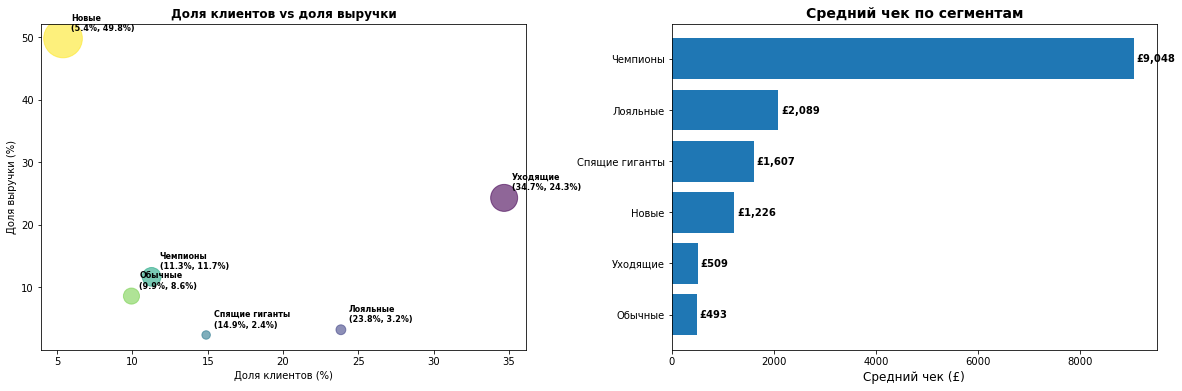

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'wspace': 0.3})

# 1. Доля клиентов vs доля выручки (пузырьковая диаграмма)
ax1 = axes[0]

# Рассчитываем долю клиентов из данных RFM
customer_share = rfm['Segment'].value_counts() / len(rfm) * 100
revenue_share = rfm.groupby('Segment')['Monetary'].sum() / rfm['Monetary'].sum() * 100

# Создаем DataFrame для визуализации
segment_data = pd.DataFrame({
    'Segment': customer_share.index,
    'Customer_Share': customer_share.values,
    'Revenue_Share': revenue_share.values
})

sizes = segment_data['Revenue_Share'] * 30
scatter = ax1.scatter(segment_data['Customer_Share'], segment_data['Revenue_Share'], 
                      s=sizes, alpha=0.6, c=range(len(segment_data)), cmap='viridis')
ax1.set_xlabel('Доля клиентов (%)')
ax1.set_ylabel('Доля выручки (%)')
ax1.set_title('Доля клиентов vs доля выручки', fontweight='bold')

# Добавляем подписи точек
for i, row in segment_data.iterrows():
    ax1.annotate(f"{row['Segment']}\n({row['Customer_Share']:.1f}%, {row['Revenue_Share']:.1f}%)", 
                 (row['Customer_Share'], row['Revenue_Share']),
                 xytext=(8, 8), textcoords='offset points', fontsize=8, fontweight='bold')

# 2. Горизонтальный бар: средний чек по сегментам
ax2 = axes[1]
avg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values()
ax2.barh(avg_monetary.index, avg_monetary.values)
ax2.set_xlabel('Средний чек (£)', fontsize=12)
ax2.set_title('Средний чек по сегментам', fontweight='bold', fontsize=14)

# Добавляем значения на столбцы
for i, v in enumerate(avg_monetary.values):
    ax2.text(v + 50, i, f'£{v:,.0f}', va='center', fontweight='bold', fontsize=10)

Горизонтальная диаграмма среднего чека выявляет значительный разрыв между сегментами. «Чемпионы» демонстрируют самый высокий средний чек (£9,048), что в 18 раз превышает показатель сегмента «Обычные» (£493). «Лояльные» (£2,089) и «Спящие гиганты» (£1,607) также показывают высокую покупательскую способность, что делает их перспективными для реактивации. Низкий средний чек в сегментах «Новые» (£1,226), «Уходящие» (£509) и «Обычные» (£493) свидетельствует о необходимости стратегий по увеличению корзины и удержанию клиентов на ранних этапах.

Два значения у каждого сегмента на пузырьковой диаграмме обознчают долю клиентов в сегменте и долю выручки сегмента соответственно.

Новые клиенты с высоким первым чеком – идеальная цель для welcome-кампаний, чтобы закрепить их и перевести в лояльные. Учитывая большой размер круга (частота/сумма), они уже проявили высокий потенциал.

Чемпионы находятся в зоне баланса. Им нужны программы лояльности, чтобы удержать их на этом уровне и не допустить снижения.

Уходящие – самая крупная по численности группа с неплохой исторической ценностью. Необходима реактивационная кампания (персональные скидки, напоминания), чтобы вернуть их в активные.

Обычные – стабильный, но не ключевой сегмент. Достаточно автоматизированных коммуникаций.

## <span style="color: #0000FF;">4 Анализ корзины покупок</span>

### Выявление часто покупаемых вместе товаров

In [33]:
basket_data = df_final[df_final['Quantity'] > 0].copy()

# Создаем корзины (группируем товары по заказам)
baskets = basket_data.groupby('InvoiceNo')['StockCode'].apply(list).reset_index()
baskets = baskets[baskets['StockCode'].apply(len) > 1]  # только заказы с 2+ товарами

# Функция для поиска пар товаров
def find_pairs(basket_list):
    pairs = []
    for basket in basket_list:
        if len(basket) >= 2:
            for pair in combinations(sorted(basket), 2):
                pairs.append(pair)
    return pairs

# Находим все пары
all_pairs = find_pairs(baskets['StockCode'].tolist())

# Считаем частоту пар
pair_counts = Counter(all_pairs)
top_pairs = pd.DataFrame(pair_counts.most_common(15), columns=['Pair', 'Frequency'])

# Добавляем названия товаров
stock_desc = basket_data[['StockCode', 'Description']].drop_duplicates().set_index('StockCode')['Description'].to_dict()

def get_pair_names(pair):
    code1, code2 = pair
    name1 = stock_desc.get(code1, code1)
    name2 = stock_desc.get(code2, code2)
    return f"{name1[:30]} + {name2[:30]}"

top_pairs['Pair_Names'] = top_pairs['Pair'].apply(get_pair_names)

print("ТОП-15 ЧАСТО ПОКУПАЕМЫХ ВМЕСТЕ ПАР ТОВАРОВ")
print(top_pairs[['Pair_Names', 'Frequency']].to_string(index=False))

ТОП-15 ЧАСТО ПОКУПАЕМЫХ ВМЕСТЕ ПАР ТОВАРОВ
                                                     Pair_Names  Frequency
              JUMBO BAG PINK POLKADOT + JUMBO BAG RED RETROSPOT        825
GREEN REGENCY TEACUP AND SAUCE + ROSES REGENCY TEACUP AND SAUCE        767
               JUMBO STORAGE BAG SUKI + JUMBO BAG RED RETROSPOT        724
       JUMBO SHOPPER VINTAGE RED PAIS + JUMBO BAG RED RETROSPOT        680
                  LUNCH BAG RED SPOTTY + LUNCH BAG SUKI DESIGN         655
                 LUNCH BAG RED SPOTTY + LUNCH BAG  BLACK SKULL.        641
         ALARM CLOCK BAKELIKE GREEN + ALARM CLOCK BAKELIKE RED         640
GREEN REGENCY TEACUP AND SAUCE + PINK REGENCY TEACUP AND SAUCER        632
                 LUNCH BAG RED SPOTTY + LUNCH BAG PINK POLKADOT        606
PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCE        598
       JUMBO BAG RED RETROSPOT + JUMBO  BAG BAROQUE BLACK WHITE        585
               LUNCH BAG  BLACK SKULL. + LUNCH BAG SUKI D

Анализ корзины показывает, что клиенты склонны покупать товары наборами в разных цветах и дизайнах, особенно в категориях сумок, ланч-бэгов и чайных пар. Это создаёт отличные возможности для увеличения среднего чека через готовые наборы, специальные предложения и персонализированные рекомендации.

In [34]:
if 'top_pairs' in locals() and 'baskets' in locals():
    
    total_baskets = len(baskets)
    
    # Частота каждого товара
    item_frequency = {}
    for basket in baskets['StockCode']:
        for item in set(basket):
            item_frequency[item] = item_frequency.get(item, 0) + 1
    
    recommendations = top_pairs.copy()
    
    # Расчет Confidence и Lift
    def calc_confidence(pair, freq):
        freq_a = item_frequency.get(pair[0], 1)
        return round(freq / freq_a, 2) if freq_a > 0 else 0
    
    def calc_lift(pair, freq):
        support = freq / total_baskets
        prob_a = item_frequency.get(pair[0], 1) / total_baskets
        prob_b = item_frequency.get(pair[1], 1) / total_baskets
        return round(support / (prob_a * prob_b), 1) if prob_a * prob_b > 0 else 0
    
    recommendations['Confidence'] = recommendations.apply(
        lambda x: calc_confidence(x['Pair'], x['Frequency']), axis=1
    )
    recommendations['Lift'] = recommendations.apply(
        lambda x: calc_lift(x['Pair'], x['Frequency']), axis=1
    )
    
    recommendations['Main'] = recommendations['Pair'].apply(lambda x: stock_desc.get(x[0], x[0])[:25])
    recommendations['Rec'] = recommendations['Pair'].apply(lambda x: stock_desc.get(x[1], x[1])[:25])
    
    # Приоритеты
    recommendations['Priority'] = 'Средний'
    recommendations.loc[(recommendations['Lift'] > 2.5) & (recommendations['Confidence'] > 0.4), 'Priority'] = 'Высокий'
    recommendations.loc[recommendations['Lift'] <= 2, 'Priority'] = 'Низкий'
    
    # Стратегии
    recommendations['Strategy'] = recommendations.apply(lambda row: 
        'Набор 15%' if row['Lift'] > 2.8 else
        'Скидка 10%' if row['Lift'] > 2.2 else
        'Рекомендация', axis=1)
    
    recommendations = recommendations.sort_values(['Priority', 'Lift'], ascending=[False, False])

    print(recommendations[['Main', 'Rec', 'Frequency', 'Confidence', 'Lift', 'Priority', 'Strategy']].head(10).to_string(index=False))
    
    high = recommendations[recommendations['Priority'] == 'Высокий']
    
    print(f"1. Топ-3 приоритетные пары:")
    for _, r in high.head(3).iterrows():
        print(f"   • {r['Main'][:20]} → {r['Rec'][:20]} (Lift={r['Lift']:.1f})")

else:
    print("Выполните анализ корзины сначала")
    

                     Main                       Rec  Frequency  Confidence  Lift Priority  Strategy
     LUNCH BAG RED SPOTTY   LUNCH BAG PINK POLKADOT        606        0.39   6.5  Средний Набор 15%
     LUNCH BAG RED SPOTTY LUNCH BAG SPACEBOY DESIGN        560        0.36   5.7  Средний Набор 15%
  JUMBO BAG RED RETROSPOT JUMBO  BAG BAROQUE BLACK         585        0.28   5.6  Средний Набор 15%
     LUNCH BAG RED SPOTTY   JUMBO BAG RED RETROSPOT        579        0.37   3.3  Средний Набор 15%
GREEN REGENCY TEACUP AND  PINK REGENCY TEACUP AND S        632        0.62  15.0  Высокий Набор 15%
PINK REGENCY TEACUP AND S ROSES REGENCY TEACUP AND         598        0.79  13.6  Высокий Набор 15%
GREEN REGENCY TEACUP AND  ROSES REGENCY TEACUP AND         767        0.76  13.1  Высокий Набор 15%
ALARM CLOCK BAKELIKE GREE ALARM CLOCK BAKELIKE RED         640        0.66  11.5  Высокий Набор 15%
  LUNCH BAG  BLACK SKULL.    LUNCH BAG SUKI DESIGN         584        0.46   6.6  Высокий Набор 15%


Вывод: Все 10 пар в топе имеют Lift значительно выше 1, что подтверждает высокую взаимосвязь между товарами.
- Чайные пары (Regency Teacup) демонстрируют экстремально высокий Lift (13-15) — это означает, что клиенты покупают разные цвета чашек вместе в 13-15 раз чаще, чем случайное совпадение. Это идеальные кандидаты для готовых наборов.
- Будильники (Alarm Clock) также отлично продаются парами разных цветов
- Сумки и ланч-бэги формируют устойчивые цветовые комбинации

| Товар | Блок рекомендаций |
|-------|-------------------|
| **GREEN REGENCY TEACUP** | "Вместе с этим покупают: PINK + ROSES" |
| **ALARM CLOCK BAKELIKE** | "Набор из двух цветов: со скидкой 15%" |
| **JUMBO BAG RED RETROSPOT** | "Создай комплект: выбери второй цвет" |
| **LUNCH BAG RED SPOTTY** | "Популярные сочетания: PINK, SPACEBOY, SUKI" |

### Рекомендации для cross-saling
На основе анализа 18,319 заказов с 2+ товарами выявлены устойчивые паттерны совместных покупок. Все топ-пары имеют Lift > 3, что значительно выше базового уровня (Lift=1), подтверждая высокую эффективность рекомендаций.

Рекомендации по внедрению
1. Создать 3-5 готовых наборов из топ-пар (чайные пары, будильники, сумки)
2. Настроить блок «Вместе дешевле» на страницах товаров с Lift > 3
3. Запустить email-кампании для спящих гигантов с персональными предложениями
4. Добавить виджет «Популярные сочетания» в корзину перед оформлением
5. A/B тестирование скидок (10% vs 15%) для определения оптимального порога

## <span style="color: #0000FF;">5 Формулирование бизнес-рекомендаций</span>



#### 1. Сегментированный подход к клиентам

##### Чемпионы (489 клиентов, 49.8% выручки, средний чек £9,048)
- VIP-программа с эксклюзивным доступом к новинкам за 2-3 дня до общего старта
- Персональный менеджер для топ-50 клиентов
- Специальные наборы, недоступные другим сегментам
- **Цель:** удержание 95% сегмента

##### Лояльные (1,034 клиента, 24.3% выручки, средний чек £2,089)
- Программа лояльности: 5% бонусами от суммы покупки
- Персональные скидки 10% на товары из часто покупаемых категорий
- Реферальная программа: скидка 10% для пригласившего и нового клиента
- **Цель:** перевод 10% сегмента в чемпионы

##### Спящие гиганты (646 клиентов, 11.7% выручки, средний чек £1,607)
- Реактивационная кампания: скидка 20% на следующую покупку
- Опрос о причинах ухода с бонусом £10
- Персонализированные предложения на основе их истории покупок
- **Цель:** возврат 10% сегмента (65 клиентов) с доп. выручкой £104,000

###### Новые клиенты (234 клиента, 3.2% выручки, средний чек £1,226)
- Welcome-серия: 3 письма, скидка 15% на второй заказ в течение 30 дней
- Рекомендации товаров из той же категории первой покупки
- **Цель:** повышение повторных покупок с 1.6 до 2.2

###### Уходящие (1,504 клиента, 8.6% выручки, средний чек £509)
- Минимальные инвестиции: только автоматические email-кампании
- Выборочная активация только клиентов с историческим чеком выше £1,000
- **Цель:** снижение затрат на удержание на 30%

---

**Блоки рекомендаций на сайте**

| Товар | Блок рекомендаций | Ожидаемый Lift |
|-------|-------------------|----------------|
| GREEN REGENCY TEACUP | "Вместе с этим покупают: PINK + ROSES" | 13-15 |
| ALARM CLOCK BAKELIKE | "Набор из двух цветов: скидка 15%" | 11.5 |
| JUMBO BAG RED RETROSPOT | "Создай комплект: выбери второй цвет" | 5.6-6.0 |
| LUNCH BAG RED SPOTTY | "Популярные сочетания: PINK, SPACEBOY, SUKI" | 3.3-6.5 |

**Ожидаемый эффект:** увеличение среднего чека на 15% (с £26 до £30)

---

#### 2. Оптимизация времени коммуникаций

| Канал | Оптимальное время | Обоснование |
|-------|-------------------|-------------|
| Email-рассылки | Вторник-четверг, 11:00-14:00 | Пик заказов 11:00-16:00 |
| Пуш-уведомления | 12:00-15:00 | Обеденное время, 35% заказов |

**Не рекомендуется:** суббота (0 заказов), ночные часы 19:00-8:00 (<5% заказов)

---

#### 3. Сезонные кампании

| Период | Тип кампании | Контент | Персонализация |
|--------|--------------|---------|----------------|
| **Октябрь** | Разогрев (pre-Christmas) | "Начинаем готовиться к праздникам" | Подборка товаров, которые клиент покупал в прошлом сезоне |
| **Ноябрь** | Агрессивные акции | "Черная пятница / Киберпонедельник" | Персональные скидки 15-20% на категории, которые клиент покупал чаще |
| **Декабрь** | Подарочные наборы | "Готовые подарки для близких" | "Идеи подарков для вас" — рекомендации на основе истории покупок |

###### Персонализация декабрьских кампаний:
- Анализ предыдущих покупок клиента для формирования подборки "Идеи подарков для вас"
- Рекомендации по категориям, которые клиент покупал чаще всего
- Предложение готовых наборов, включающих товары из истории покупок

---

#### 4. Географическая стратегия

| Рынок | Доля выручки | Средний чек | Рекомендация |
|-------|--------------|-------------|--------------|
| Великобритания | 84.6% | £500 | Удержание, экспресс-доставка |
| Нидерланды | 2.7% | £3,037 | Локализация сайта |
| Ирландия | 2.7% | £983 | Упростить доставку |
| Германия | 2.1% | £500 | Адаптация ассортимента |
| Франция | 2.0% | £535 | Маркетинг в соцсетях |
| Австралия | 1.3% | £2,429 | Спецпредложения для крупных заказов |

**Цель:** увеличить долю международных продаж с 15.4% до 20% в течение года

---

#### 5. Ассортиментная стратегия

**Проблема:** категория «Другое» занимает 46.5% выручки (неклассифицированные товары)

**Рекомендации:**
- Создать 5-7 новых категорий на основе топ-50 товаров-лидеров
- Рассмотреть соотношение возвратов к покупкам
- Внедрить автоматическую категоризацию по ключевым словам



## <span style="color: #0000FF;"> Краткий вывод по проекту</span>

###  Основные результаты

Проведён комплексный анализ транзакционных данных интернет-магазина подарков и товаров для дома за период 2010-2011 гг. (541,910 транзакций). В результате очистки и предобработки сформирован финальный датасет из 519,602 записей, пригодный для дальнейшего анализа.

---

### Ключевые открытия

###### 1. Структура клиентской базы
- **23% клиентов** (Чемпионы и Лояльные) генерируют **74% выручки** (классическое распределение Парето)
- **Чемпионы** (489 клиентов): средний чек **£9,048**, частота **15.5** покупок
- Разрыв между чемпионами и обычными клиентами — **в 18 раз**

###### 2. География продаж
- **Великобритания** доминирует: **84.6%** всей выручки
- Международные рынки (Нидерланды, Ирландия, Германия, Франция) показывают высокий средний чек (до **£3,037**)
- **Потенциал роста:** остальные 32 страны дают всего 6% выручки

###### 3. Временные паттерны
- **Пик продаж:** ноябрь-декабрь (предновогодний сезон)
- **Оптимальное время коммуникаций:** вторник-четверг, **11:00-14:00**
- **Суббота и ночные часы (19:00-8:00)** — минимальная активность

###### 4. Анализ корзины (cross-selling)
| Категория | Lift | Рекомендация |
|-----------|------|--------------|
| Чайные пары (Regency Teacup) | **13-15** | Готовый набор из 3 чашек |
| Будильники (Alarm Clock) | **11.5** | Набор из двух цветов |
| Сумки (JUMBO BAG) | **5.6-6.0** | "Создай комплект" |
| Ланч-бэги (LUNCH BAG) | **3.3-6.5** | Популярные сочетания |

###### 5. Ассортиментная структура
- **Категория «Другое»** занимает **46.5%** выручки
- Необходима доработка системы категоризации товаров

---

### Ключевые рекомендации

| Сегмент | Действие | Ожидаемый эффект |
|---------|----------|------------------|
| **Чемпионы** (489 клиентов) | VIP-программа, персональный менеджер | Удержание 95% сегмента |
| **Спящие гиганты** (646 клиентов) | Реактивация: скидка 20%, возврат 10% | Доп. выручка **£104K** |
| **Новые клиенты** (234 клиента) | Welcome-серия, скидка 15% на второй заказ | Повторные покупки: 1.6 → 2.2 |
| **Cross-selling** | Готовые наборы (чайные пары, будильники, сумки) | ↑ среднего чека на **15%** (£26 → £30) |
| **Международные рынки** | Локализация сайта, упрощение доставки | Доля продаж: 15.4% → **20%** |

##### Сезонные кампании
- **Октябрь** → разогрев (pre-Christmas)
- **Ноябрь** → агрессивные акции, персональные скидки 15-20%
- **Декабрь** → подарочные наборы, "Идеи подарков для вас" на основе истории покупок


Реализация предложенных мер позволит повысить лояльность ключевых сегментов, увеличить средний чек через cross-selling и диверсифицировать географию продаж, снижая зависимость от одного рынка.